In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize']    = (16, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:

OUR_OPERATOR_NAME = 'OurBus'


THRESHOLD_HIGH     =  20
THRESHOLD_MID_HIGH =  10
THRESHOLD_MID_LOW  = -10
THRESHOLD_LOW      = -20


MIN_PEER_GROUP_SIZE = 2

print('✅ Configuration ready!')
print(f'   Operator          : {OUR_OPERATOR_NAME}')
print(f'   Flag Too High     : > +{THRESHOLD_HIGH}%')
print(f'   Flag Too Low      : < {THRESHOLD_LOW}%')
print(f'   Min peer group    : {MIN_PEER_GROUP_SIZE} buses')

✅ Configuration ready!
   Operator          : OurBus
   Flag Too High     : > +20%
   Flag Too Low      : < -20%
   Min peer group    : 2 buses


In [3]:


import random
random.seed(42)
np.random.seed(42)

n = 500

routes     = ['Delhi-Agra', 'Mumbai-Pune', 'Bangalore-Chennai', 'Hyderabad-Vizag', 'Jaipur-Delhi']
bus_types  = ['AC Sleeper', 'Non-AC Seater', 'AC Seater', 'Luxury']
operators  = [OUR_OPERATOR_NAME, 'CompetitorA', 'CompetitorB', 'CompetitorC', 'CompetitorD']


price_ranges = {
    'AC Sleeper'    : (800, 2500),
    'Non-AC Seater' : (200, 700),
    'AC Seater'     : (400, 1200),
    'Luxury'        : (1200, 3000)
}

bus_type_col = [random.choice(bus_types) for _ in range(n)]
price_col    = [round(random.uniform(*price_ranges[bt]), 0) for bt in bus_type_col]

df = pd.DataFrame({
    'bus_id'         : range(1, n + 1),
    'operator'       : [random.choices(operators, weights=[20, 25, 25, 20, 10])[0] for _ in range(n)],
    'route'          : [random.choice(routes) for _ in range(n)],
    'bus_type'       : bus_type_col,
    'departure_hour' : [random.choice(range(0, 24)) for _ in range(n)],
    'price'          : price_col,
    'avg_rating'     : [round(random.uniform(2.5, 5.0), 1) for _ in range(n)],
    'num_reviews'    : [random.randint(5, 3000) for _ in range(n)],
    'load_pct'       : [round(random.uniform(10, 100), 1) for _ in range(n)],
    'search_rank'    : [random.randint(1, 30) for _ in range(n)],
})

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Operators : {df["operator"].unique().tolist()}')
print(f'   Routes    : {df["route"].nunique()} unique routes')
print(f'   Bus types : {df["bus_type"].unique().tolist()}')
display(df.head(8))

✅ Dataset loaded: 500 rows × 10 columns
   Operators : ['CompetitorC', 'CompetitorB', 'OurBus', 'CompetitorA', 'CompetitorD']
   Routes    : 5 unique routes
   Bus types : ['AC Sleeper', 'AC Seater', 'Non-AC Seater', 'Luxury']


,bus_id,operator,route,bus_type,departure_hour,price,avg_rating,num_reviews,load_pct,search_rank
0,1,CompetitorC,Bangalore-Chennai,AC Sleeper,18,885.0,4.4,1249,23.3,8
1,2,CompetitorB,Bangalore-Chennai,AC Sleeper,3,1444.0,4.3,2555,95.4,9
2,3,CompetitorB,Hyderabad-Vizag,AC Seater,1,569.0,3.9,998,50.4,13
3,4,CompetitorB,Jaipur-Delhi,Non-AC Seater,17,363.0,5.0,1905,95.4,11
4,5,CompetitorB,Delhi-Agra,Non-AC Seater,16,581.0,3.1,1513,25.0,10
5,6,OurBus,Jaipur-Delhi,Non-AC Seater,6,390.0,3.8,2428,29.1,15
6,7,CompetitorC,Mumbai-Pune,AC Sleeper,18,2078.0,4.2,2025,27.3,26
7,8,CompetitorA,Hyderabad-Vizag,AC Sleeper,17,2214.0,2.9,805,13.8,5


In [4]:


print('=== BEFORE CLEANING ===')
print(f'Rows             : {df.shape[0]}')
print(f'Columns          : {df.shape[1]}')
print(f'Duplicate rows   : {df.duplicated().sum()}')
print(f'\nMissing values:')
print(df.isnull().sum().to_string())


df = df.drop_duplicates()


df = df.dropna(subset=['price', 'avg_rating', 'route', 'bus_type', 'operator'])


df['price']       = pd.to_numeric(df['price'],       errors='coerce')
df['avg_rating']  = pd.to_numeric(df['avg_rating'],  errors='coerce')
df['num_reviews'] = pd.to_numeric(df['num_reviews'], errors='coerce').fillna(0).astype(int)
df['load_pct']    = pd.to_numeric(df['load_pct'],    errors='coerce')
df['search_rank'] = pd.to_numeric(df['search_rank'], errors='coerce')


for col in ['route', 'bus_type', 'operator']:
    df[col] = df[col].astype(str).str.strip().str.title()


OUR_OPERATOR_NAME = OUR_OPERATOR_NAME.title()


df = df[df['price'] > 0]
df = df[df['avg_rating'].between(1.0, 5.0)]
df = df[df['load_pct'].between(0, 100)]


df = df.dropna(subset=['price', 'avg_rating'])
df = df.reset_index(drop=True)

print(f'\n=== AFTER CLEANING ===')
print(f'Rows             : {df.shape[0]}')
print(f'Rows removed     : {500 - df.shape[0]}')
print('✅ Data is clean!')

=== BEFORE CLEANING ===
Rows             : 500
Columns          : 10
Duplicate rows   : 0

Missing values:
bus_id            0
operator          0
route             0
bus_type          0
departure_hour    0
price             0
avg_rating        0
num_reviews       0
load_pct          0
search_rank       0

=== AFTER CLEANING ===
Rows             : 500
Rows removed     : 0
✅ Data is clean!


In [5]:

def time_bucket(hour):
    if 5 <= hour < 12:   return 'Morning'
    elif 12 <= hour < 18: return 'Afternoon'
    elif 18 <= hour < 23: return 'Evening'
    else:                 return 'Night'

df['time_bucket'] = df['departure_hour'].apply(time_bucket)


def rating_tier(r):
    if r >= 4.2:   return 'Tier_A'
    elif r >= 3.5: return 'Tier_B'
    else:          return 'Tier_C'

df['rating_tier'] = df['avg_rating'].apply(rating_tier)


df['similarity_key'] = (
    df['route']       + '__' +
    df['bus_type']    + '__' +
    df['rating_tier']
)


df['is_our_bus'] = (df['operator'] == OUR_OPERATOR_NAME)


group_sizes = df.groupby('similarity_key').size()
valid_groups = (group_sizes >= MIN_PEER_GROUP_SIZE).sum()

print('✅ Feature engineering done!')
print(f'\n📊 Time bucket distribution:')
print(df['time_bucket'].value_counts().to_string())
print(f'\n⭐ Rating tier distribution:')
print(df['rating_tier'].value_counts().to_string())
print(f'\n🔑 Similarity groups summary:')
print(f'   Total groups           : {group_sizes.shape[0]}')
print(f'   Groups with ≥{MIN_PEER_GROUP_SIZE} buses   : {valid_groups}  ← will be flagged')
print(f'   Groups with  1 bus     : {(group_sizes == 1).sum()}  ← will be Insufficient Data')
print(f'   Avg buses per group    : {group_sizes.mean():.1f}')
print(f'\n🚌 Our bus rows           : {df["is_our_bus"].sum()}')
print(f'🏢 Competitor rows        : {(~df["is_our_bus"]).sum()}')

display(df[['route','bus_type','avg_rating','rating_tier','similarity_key']].drop_duplicates().head(10))

✅ Feature engineering done!

📊 Time bucket distribution:
time_bucket
Afternoon    141
Night        134
Morning      130
Evening       95

⭐ Rating tier distribution:
rating_tier
Tier_C    187
Tier_A    170
Tier_B    143

🔑 Similarity groups summary:
   Total groups           : 60
   Groups with ≥2 buses   : 60  ← will be flagged
   Groups with  1 bus     : 0  ← will be Insufficient Data
   Avg buses per group    : 8.3

🚌 Our bus rows           : 105
🏢 Competitor rows        : 395


,route,bus_type,avg_rating,rating_tier,similarity_key
0,Bangalore-Chennai,Ac Sleeper,4.4,Tier_A,Bangalore-Chennai__Ac Sleeper__Tier_A
1,Bangalore-Chennai,Ac Sleeper,4.3,Tier_A,Bangalore-Chennai__Ac Sleeper__Tier_A
2,Hyderabad-Vizag,Ac Seater,3.9,Tier_B,Hyderabad-Vizag__Ac Seater__Tier_B
3,Jaipur-Delhi,Non-Ac Seater,5.0,Tier_A,Jaipur-Delhi__Non-Ac Seater__Tier_A
4,Delhi-Agra,Non-Ac Seater,3.1,Tier_C,Delhi-Agra__Non-Ac Seater__Tier_C
5,Jaipur-Delhi,Non-Ac Seater,3.8,Tier_B,Jaipur-Delhi__Non-Ac Seater__Tier_B
6,Mumbai-Pune,Ac Sleeper,4.2,Tier_A,Mumbai-Pune__Ac Sleeper__Tier_A
7,Hyderabad-Vizag,Ac Sleeper,2.9,Tier_C,Hyderabad-Vizag__Ac Sleeper__Tier_C
8,Bangalore-Chennai,Luxury,3.2,Tier_C,Bangalore-Chennai__Luxury__Tier_C
9,Bangalore-Chennai,Ac Sleeper,3.2,Tier_C,Bangalore-Chennai__Ac Sleeper__Tier_C


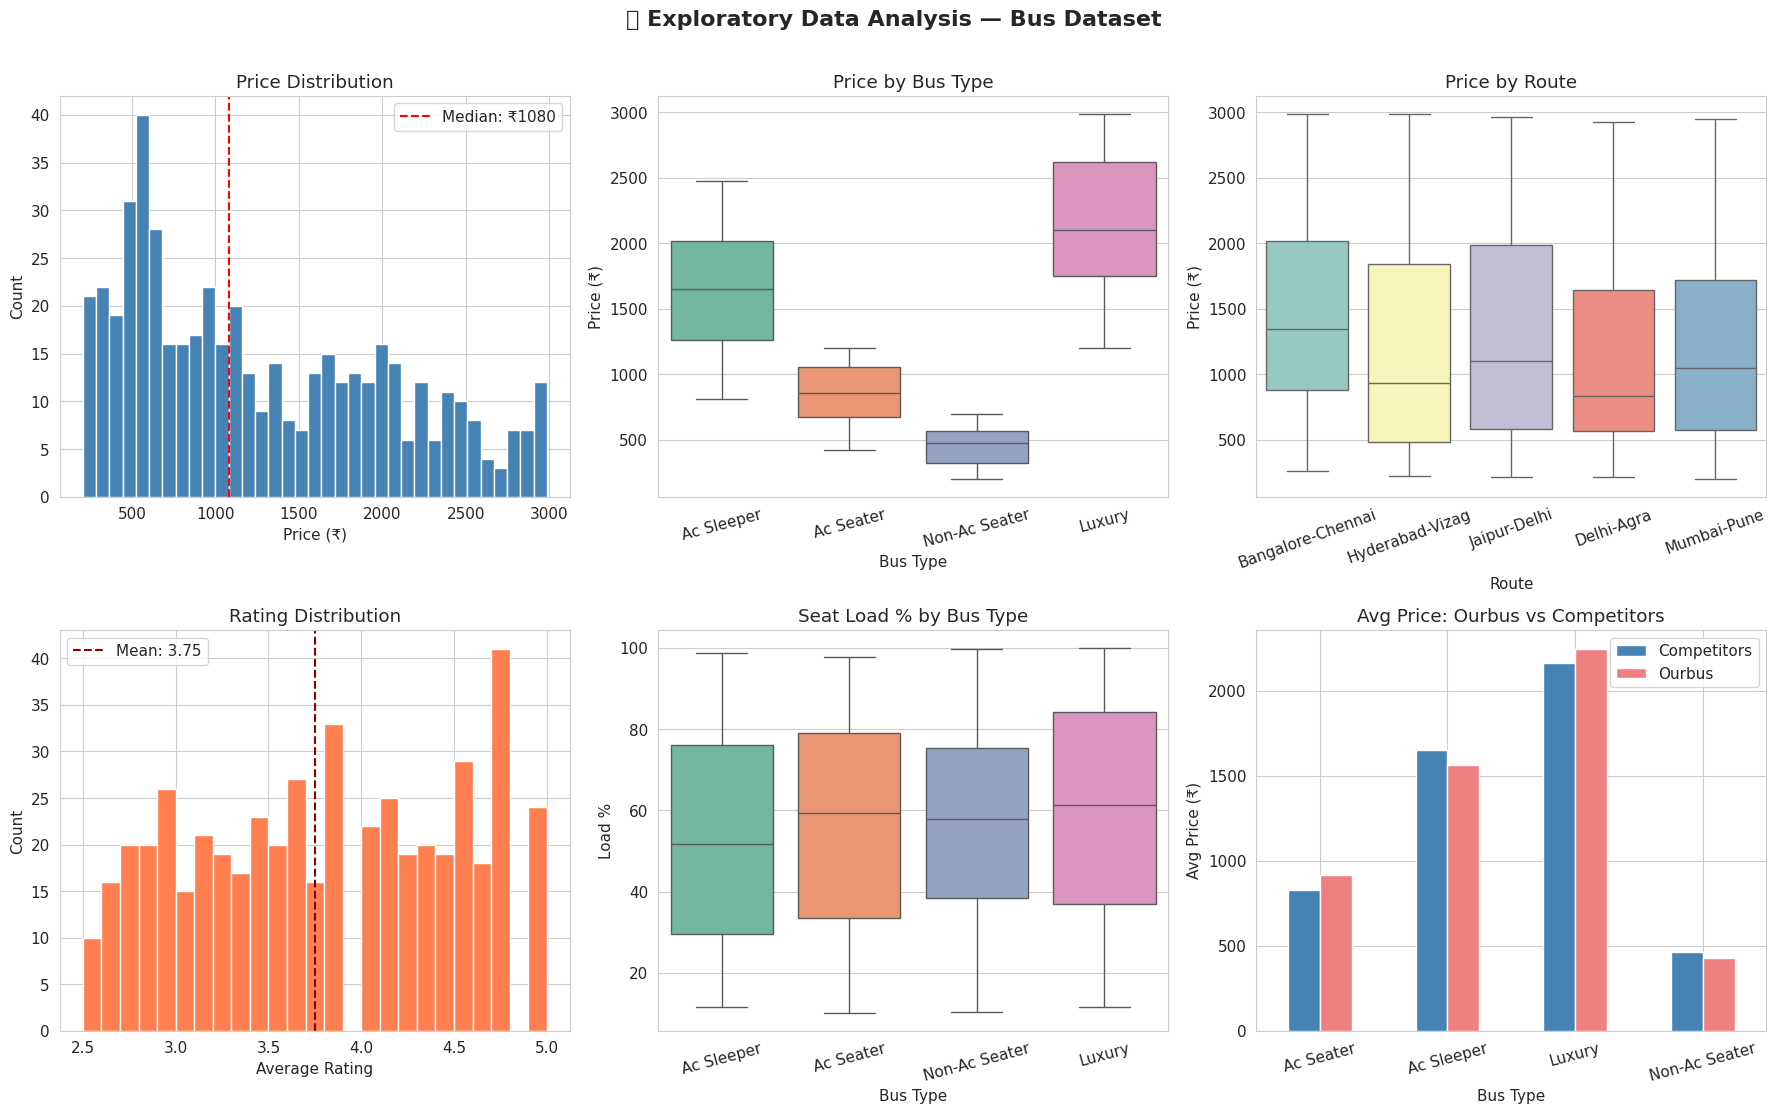


📋 KEY STATISTICS
         price  avg_rating  load_pct  search_rank
count   500.00      500.00    500.00       500.00
mean   1270.84        3.75     56.31        15.91
std     774.25        0.71     25.80         8.54
min     205.00        2.50     10.20         1.00
25%     581.00        3.10     34.88         8.75
50%    1080.50        3.75     56.80        17.00
75%    1884.50        4.40     79.18        23.00
max    2987.00        5.00     99.90        30.00

✅ EDA complete! Saved: eda_charts.png


In [6]:


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('📊 Exploratory Data Analysis — Bus Dataset', fontsize=16, fontweight='bold', y=1.01)


axes[0,0].hist(df['price'], bins=35, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['price'].median(), color='red', linestyle='--', linewidth=1.5,
                  label=f'Median: ₹{df["price"].median():.0f}')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()


sns.boxplot(x='bus_type', y='price', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Price by Bus Type')
axes[0,1].set_xlabel('Bus Type')
axes[0,1].set_ylabel('Price (₹)')
axes[0,1].tick_params(axis='x', rotation=15)


sns.boxplot(x='route', y='price', data=df, ax=axes[0,2], palette='Set3')
axes[0,2].set_title('Price by Route')
axes[0,2].set_xlabel('Route')
axes[0,2].set_ylabel('Price (₹)')
axes[0,2].tick_params(axis='x', rotation=20)


axes[1,0].hist(df['avg_rating'], bins=25, color='coral', edgecolor='white')
axes[1,0].axvline(df['avg_rating'].mean(), color='darkred', linestyle='--', linewidth=1.5,
                  label=f'Mean: {df["avg_rating"].mean():.2f}')
axes[1,0].set_title('Rating Distribution')
axes[1,0].set_xlabel('Average Rating')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()


sns.boxplot(x='bus_type', y='load_pct', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Seat Load % by Bus Type')
axes[1,1].set_xlabel('Bus Type')
axes[1,1].set_ylabel('Load %')
axes[1,1].tick_params(axis='x', rotation=15)


price_compare = df.groupby(['bus_type', 'is_our_bus'])['price'].mean().unstack()
price_compare.columns = [OUR_OPERATOR_NAME if c else 'Competitors' for c in price_compare.columns]
price_compare.plot(kind='bar', ax=axes[1,2], color=['steelblue', 'lightcoral'], edgecolor='white')
axes[1,2].set_title(f'Avg Price: {OUR_OPERATOR_NAME} vs Competitors')
axes[1,2].set_xlabel('Bus Type')
axes[1,2].set_ylabel('Avg Price (₹)')
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 KEY STATISTICS')
print('=' * 50)
print(df[['price','avg_rating','load_pct','search_rank']].describe().round(2).to_string())
print('\n✅ EDA complete! Saved: eda_charts.png')

In [7]:

group_stats = df.groupby('similarity_key')['price'].agg(
    group_median = 'median',
    group_mean   = 'mean',
    group_std    = 'std',
    group_min    = 'min',
    group_max    = 'max',
    group_q25    = lambda x: x.quantile(0.25),
    group_q75    = lambda x: x.quantile(0.75),
    group_count  = 'count'
).reset_index()

group_stats['group_iqr'] = (group_stats['group_q75'] - group_stats['group_q25']).round(2)
group_stats = group_stats.round(2)


df = df.merge(group_stats, on='similarity_key', how='left')


df['enough_peers'] = df['group_count'] >= MIN_PEER_GROUP_SIZE


df['price_variance_pct'] = (
    (df['price'] - df['group_median']) / df['group_median'] * 100
).round(2)


df['price_gap_inr'] = (df['price'] - df['group_median']).round(2)


print('✅ Peer group benchmarks calculated!')
print(f'\n   Total groups            : {group_stats.shape[0]}')
print(f'   Groups with ≥{MIN_PEER_GROUP_SIZE} buses    : {(group_stats["group_count"] >= MIN_PEER_GROUP_SIZE).sum()}')
print(f'   Groups with 1 bus       : {(group_stats["group_count"] == 1).sum()} (Insufficient Data)')
print(f'   Avg buses per group     : {group_stats["group_count"].mean():.1f}')
print(f'   Max buses in one group  : {group_stats["group_count"].max()}')

print('\n📊 Sample peer group stats (first 6 groups):')
display(group_stats.head(6))

✅ Peer group benchmarks calculated!

   Total groups            : 60
   Groups with ≥2 buses    : 60
   Groups with 1 bus       : 0 (Insufficient Data)
   Avg buses per group     : 8.3
   Max buses in one group  : 21

📊 Sample peer group stats (first 6 groups):


,similarity_key,group_median,group_mean,group_std,group_min,group_max,group_q25,group_q75,group_count,group_iqr
0,Bangalore-Chennai__Ac Seater__Tier_A,954.0,947.12,158.56,644.0,1198.0,916.75,994.50,8,77.75
1,Bangalore-Chennai__Ac Seater__Tier_B,1011.5,964.75,246.96,429.0,1184.0,914.00,1140.50,8,226.50
2,Bangalore-Chennai__Ac Seater__Tier_C,728.0,728.57,226.55,441.0,1087.0,566.00,856.00,7,290.00
3,Bangalore-Chennai__Ac Sleeper__Tier_A,1789.0,1693.92,528.36,885.0,2473.0,1291.00,2183.00,13,892.00
4,Bangalore-Chennai__Ac Sleeper__Tier_B,1450.5,1463.50,465.51,878.0,2144.0,1067.75,1848.25,10,780.50
5,Bangalore-Chennai__Ac Sleeper__Tier_C,1719.0,1617.50,491.51,939.0,2225.0,1173.50,2017.00,10,843.50


In [8]:

def price_flag(row):
    if not row['enough_peers']:
        return '⚪ Insufficient Data'
    v = row['price_variance_pct']
    if   v > THRESHOLD_HIGH:     return '🔴 Too High'
    elif v > THRESHOLD_MID_HIGH: return '🟡 Slightly High'
    elif v < THRESHOLD_LOW:      return '🔴 Too Low'
    elif v < THRESHOLD_MID_LOW:  return '🟡 Slightly Low'
    else:                        return '🟢 Fair'

df['price_flag'] = df.apply(price_flag, axis=1)


print('=' * 58)
print('  📋 PRICE FLAG SUMMARY — ALL BUSES')
print('=' * 58)
all_flags = df['price_flag'].value_counts()
total     = len(df)
for flag, count in all_flags.items():
    print(f'  {flag:<30} {count:>4}  ({count/total*100:.1f}%)')


our_buses = df[df['is_our_bus']].copy()

print(f'\n{"=" * 58}')
print(f'  🚌 PRICE FLAG SUMMARY — {OUR_OPERATOR_NAME.upper()}')
print(f'{"=" * 58}')

if len(our_buses) == 0:
    print(f'  ⚠️  No rows found for operator: "{OUR_OPERATOR_NAME}"')
    print('  → Check OUR_OPERATOR_NAME in Cell 2')
else:
    our_flags  = our_buses['price_flag'].value_counts()
    our_total  = len(our_buses)
    for flag, count in our_flags.items():
        print(f'  {flag:<30} {count:>4}  ({count/our_total*100:.1f}%)')
    print(f'\n  Total routes analysed  : {our_total}')
    actionable = our_buses[our_buses['price_flag'].isin(['🔴 Too High','🟡 Slightly High','🔴 Too Low','🟡 Slightly Low'])]
    print(f'  Actionable flags       : {len(actionable)} rows need pricing review')
    print(f'  Avg price variance     : {our_buses["price_variance_pct"].mean():.1f}%')
print('=' * 58)

print('\n🔎 Our bus rows — sorted by variance (worst first):')
display(
    our_buses[['route','bus_type','rating_tier','price','group_median',
               'price_gap_inr','price_variance_pct','group_count','price_flag']]
    .sort_values('price_variance_pct', ascending=False)
    .reset_index(drop=True)
)

  📋 PRICE FLAG SUMMARY — ALL BUSES
  🟢 Fair                          161  (32.2%)
  🔴 Too Low                       125  (25.0%)
  🔴 Too High                      117  (23.4%)
  🟡 Slightly High                  50  (10.0%)
  🟡 Slightly Low                   47  (9.4%)

  🚌 PRICE FLAG SUMMARY — OURBUS
  🟢 Fair                           32  (30.5%)
  🔴 Too High                       26  (24.8%)
  🔴 Too Low                        25  (23.8%)
  🟡 Slightly High                  16  (15.2%)
  🟡 Slightly Low                    6  (5.7%)

  Total routes analysed  : 105
  Actionable flags       : 73 rows need pricing review
  Avg price variance     : 0.8%

🔎 Our bus rows — sorted by variance (worst first):


,route,bus_type,rating_tier,price,group_median,price_gap_inr,price_variance_pct,group_count,price_flag
0,Delhi-Agra,Luxury,Tier_C,2925.0,1892.0,1033.0,54.60,3,🔴 Too High
1,Mumbai-Pune,Non-Ac Seater,Tier_C,681.0,442.0,239.0,54.07,9,🔴 Too High
2,Mumbai-Pune,Ac Sleeper,Tier_A,2337.0,1523.0,814.0,53.45,9,🔴 Too High
3,Bangalore-Chennai,Luxury,Tier_C,2941.0,1971.0,970.0,49.21,21,🔴 Too High
4,Delhi-Agra,Non-Ac Seater,Tier_C,570.0,390.0,180.0,46.15,8,🔴 Too High
...,...,...,...,...,...,...,...,...,...
100,Bangalore-Chennai,Ac Sleeper,Tier_A,1031.0,1789.0,-758.0,-42.37,13,🔴 Too Low
101,Delhi-Agra,Non-Ac Seater,Tier_C,214.0,390.0,-176.0,-45.13,8,🔴 Too Low
102,Hyderabad-Vizag,Ac Seater,Tier_A,461.0,880.0,-419.0,-47.61,10,🔴 Too Low
103,Jaipur-Delhi,Non-Ac Seater,Tier_A,245.0,485.0,-240.0,-49.48,14,🔴 Too Low


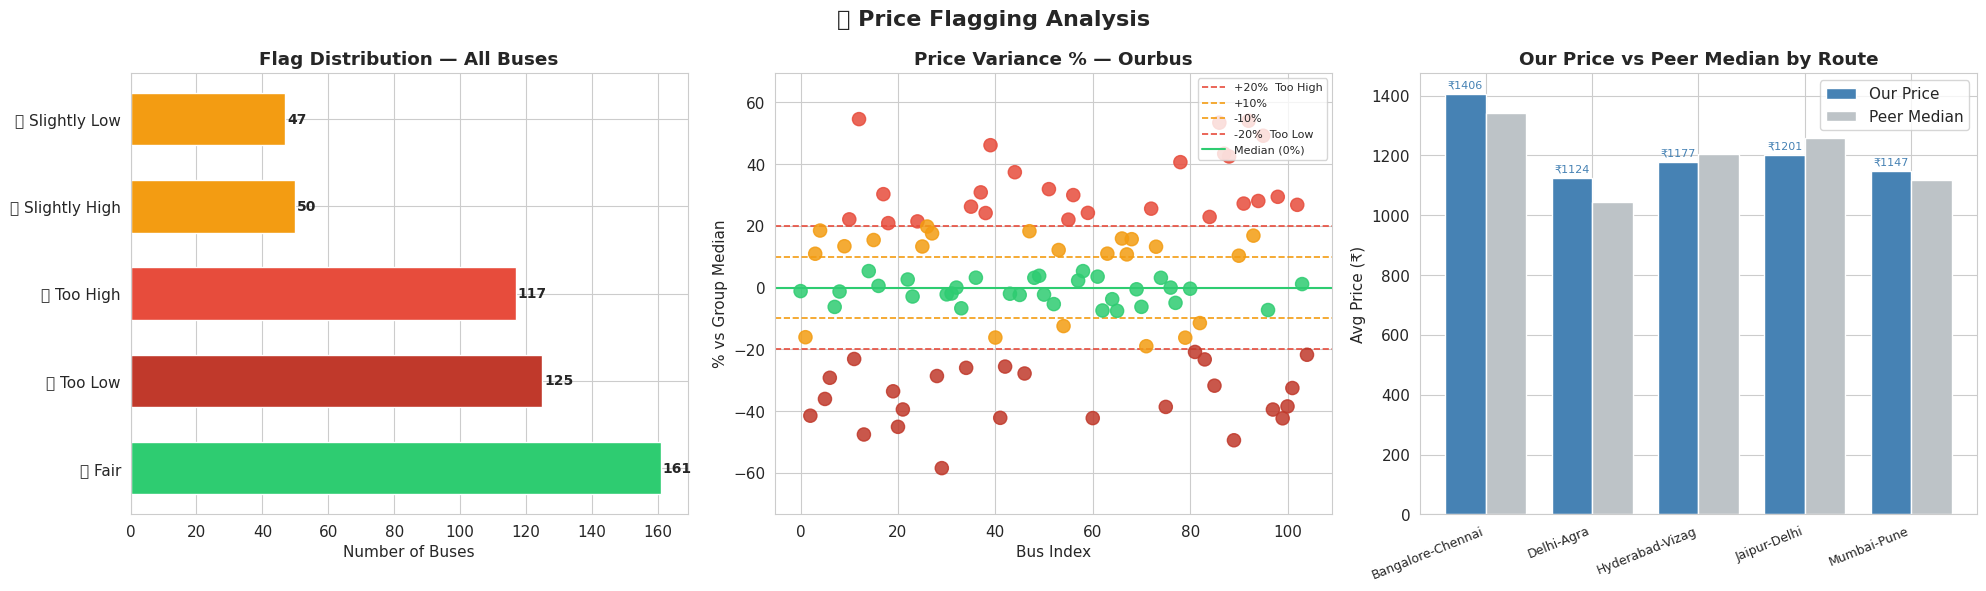

✅ Saved: flagging_analysis.png


In [9]:


COLOR_MAP = {
    '🔴 Too High'          : '#e74c3c',
    '🟡 Slightly High'     : '#f39c12',
    '🟢 Fair'              : '#2ecc71',
    '🟡 Slightly Low'      : '#f39c12',
    '🔴 Too Low'           : '#c0392b',
    '⚪ Insufficient Data' : '#bdc3c7'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🚩 Price Flagging Analysis', fontsize=16, fontweight='bold')


flag_counts = df['price_flag'].value_counts()
bar_colors  = [COLOR_MAP.get(f, '#95a5a6') for f in flag_counts.index]
bars = axes[0].barh(flag_counts.index, flag_counts.values, color=bar_colors, edgecolor='white', height=0.6)
axes[0].set_title('Flag Distribution — All Buses', fontweight='bold')
axes[0].set_xlabel('Number of Buses')
for bar, val in zip(bars, flag_counts.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold', fontsize=10)


if len(our_buses) > 0:
    scatter_colors = [COLOR_MAP.get(f, '#95a5a6') for f in our_buses['price_flag']]
    axes[1].scatter(range(len(our_buses)), our_buses['price_variance_pct'].values,
                    c=scatter_colors, s=90, alpha=0.85, zorder=3)
    for thresh, color, lbl in [
        ( THRESHOLD_HIGH,     '#e74c3c', f'+{THRESHOLD_HIGH}%  Too High'),
        ( THRESHOLD_MID_HIGH, '#f39c12', f'+{THRESHOLD_MID_HIGH}%'),
        ( THRESHOLD_MID_LOW,  '#f39c12', f'{THRESHOLD_MID_LOW}%'),
        ( THRESHOLD_LOW,      '#e74c3c', f'{THRESHOLD_LOW}%  Too Low'),
    ]:
        axes[1].axhline(y=thresh, color=color, linestyle='--', linewidth=1.2, label=lbl)
    axes[1].axhline(y=0, color='#2ecc71', linestyle='-', linewidth=1.5, label='Median (0%)')
    axes[1].set_title(f'Price Variance % — {OUR_OPERATOR_NAME}', fontweight='bold')
    axes[1].set_ylabel('% vs Group Median')
    axes[1].set_xlabel('Bus Index')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].set_ylim(
        our_buses['price_variance_pct'].min() - 15,
        our_buses['price_variance_pct'].max() + 15
    )


if len(our_buses) > 0:
    route_compare = our_buses.groupby('route')[['price','group_median']].mean().round(0)
    x     = np.arange(len(route_compare))
    width = 0.38
    b1 = axes[2].bar(x - width/2, route_compare['price'],
                     width=width, label='Our Price', color='steelblue', edgecolor='white')
    b2 = axes[2].bar(x + width/2, route_compare['group_median'],
                     width=width, label='Peer Median', color='#bdc3c7', edgecolor='white')
    for bar in b1:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'₹{bar.get_height():.0f}', ha='center', fontsize=8, color='steelblue')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(route_compare.index, rotation=22, ha='right', fontsize=9)
    axes[2].set_title(f'Our Price vs Peer Median by Route', fontweight='bold')
    axes[2].set_ylabel('Avg Price (₹)')
    axes[2].legend()

plt.tight_layout()
plt.savefig('flagging_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: flagging_analysis.png')

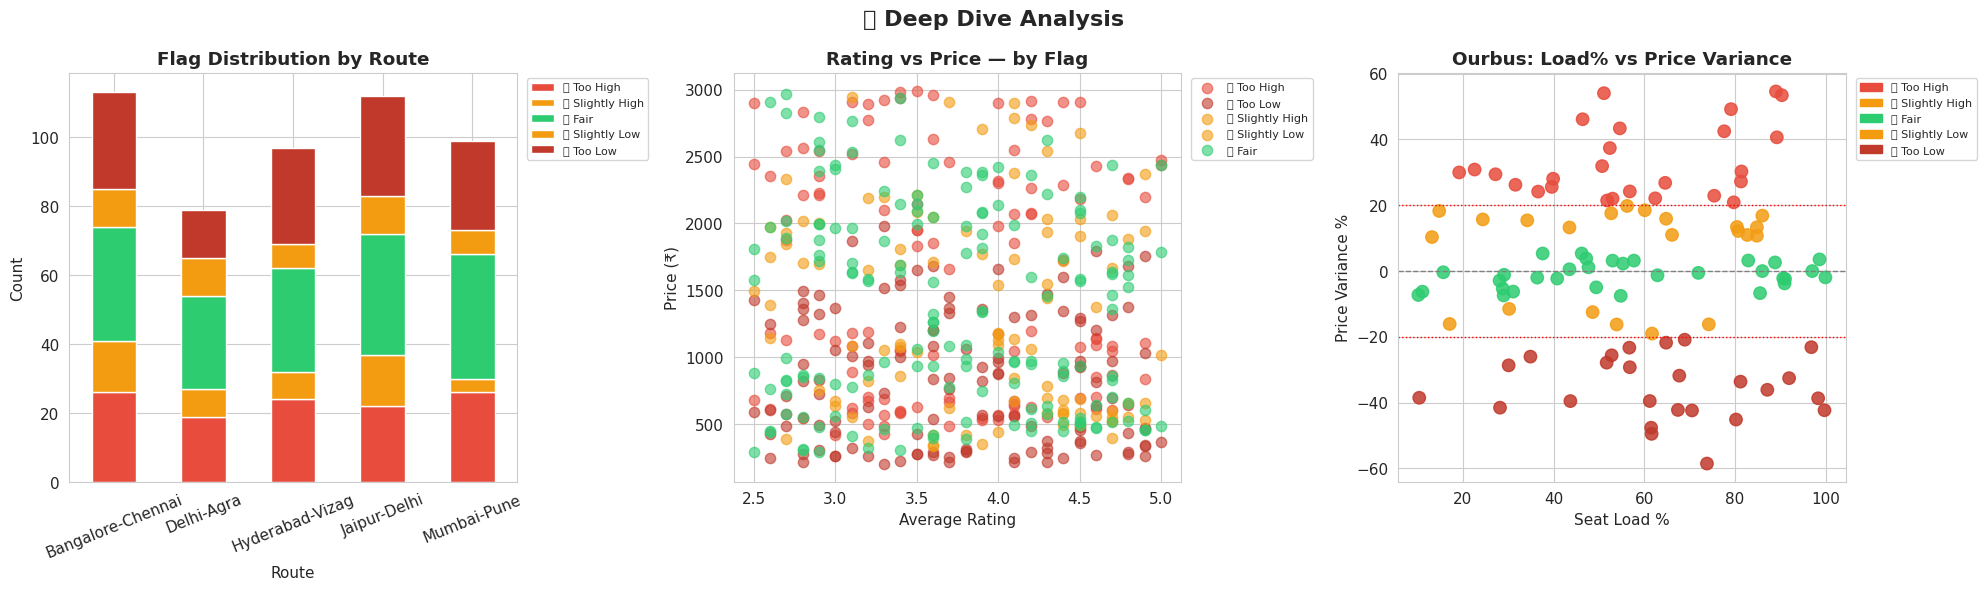

✅ Saved: deep_dive_charts.png


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('📈 Deep Dive Analysis', fontsize=16, fontweight='bold')


flag_order  = ['🔴 Too High','🟡 Slightly High','🟢 Fair','🟡 Slightly Low','🔴 Too Low','⚪ Insufficient Data']
route_flags = df.groupby(['route','price_flag']).size().unstack(fill_value=0)
route_flags = route_flags.reindex(columns=[f for f in flag_order if f in route_flags.columns])
route_flags.plot(kind='bar', ax=axes[0], stacked=True,
                 color=[COLOR_MAP.get(c, '#95a5a6') for c in route_flags.columns],
                 edgecolor='white')
axes[0].set_title('Flag Distribution by Route', fontweight='bold')
axes[0].set_xlabel('Route')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=22)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)


for flag_val, grp in df[df['enough_peers']].groupby('price_flag'):
    axes[1].scatter(grp['avg_rating'], grp['price'],
                    label=flag_val, alpha=0.6, s=55,
                    color=COLOR_MAP.get(flag_val, '#95a5a6'))
axes[1].set_title('Rating vs Price — by Flag', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Price (₹)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)


our_valid = our_buses[our_buses['enough_peers']].copy()
if len(our_valid) > 0:
    scatter_c = [COLOR_MAP.get(f, '#95a5a6') for f in our_valid['price_flag']]
    axes[2].scatter(our_valid['load_pct'], our_valid['price_variance_pct'],
                    c=scatter_c, s=80, alpha=0.85)
    axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=1)
    axes[2].axhline(y= THRESHOLD_HIGH,     color='red',    linestyle=':', linewidth=1)
    axes[2].axhline(y= THRESHOLD_LOW,      color='red',    linestyle=':', linewidth=1)
    axes[2].set_title(f'{OUR_OPERATOR_NAME}: Load% vs Price Variance', fontweight='bold')
    axes[2].set_xlabel('Seat Load %')
    axes[2].set_ylabel('Price Variance %')

    legend_patches = [mpatches.Patch(color=c, label=f) for f, c in COLOR_MAP.items()
                      if f in our_valid['price_flag'].values]
    axes[2].legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'No valid our-bus data', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('deep_dive_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: deep_dive_charts.png')

In [11]:


output_cols = [
    'bus_id', 'operator', 'route', 'bus_type',
    'departure_hour', 'time_bucket',
    'avg_rating', 'rating_tier', 'num_reviews',
    'load_pct', 'search_rank',
    'price', 'group_median', 'group_count',
    'price_gap_inr', 'price_variance_pct', 'price_flag',
    'similarity_key'
]

final_df  = df[output_cols].copy()
our_final = final_df[final_df['operator'] == OUR_OPERATOR_NAME].copy()


final_df.to_csv('bus_price_flagging_output.csv', index=False)


our_final.to_csv('our_bus_flags_only.csv', index=False)


action_flags = ['🔴 Too High', '🟡 Slightly High', '🔴 Too Low', '🟡 Slightly Low']
action_df    = our_final[our_final['price_flag'].isin(action_flags)].copy()
action_df.sort_values('price_variance_pct', ascending=False, inplace=True)
action_df.to_csv('action_required_flags.csv', index=False)

print('✅ ALL EXPORTS COMPLETE!')
print('─' * 52)
print('  📄 bus_price_flagging_output.csv — All 500 rows')
print(f'  📄 our_bus_flags_only.csv        — {len(our_final)} our-bus rows')
print(f'  📄 action_required_flags.csv     — {len(action_df)} rows needing review')
print('  🖼️  eda_charts.png')
print('  🖼️  flagging_analysis.png')
print('  🖼️  deep_dive_charts.png')
print('─' * 52)
print('  📁 Left sidebar → Files → right-click → Download')

print(f'\n🔎 ACTION REQUIRED — {len(action_df)} rows (sorted by severity):')
display(
    action_df[['route','bus_type','rating_tier','price','group_median',
               'price_gap_inr','price_variance_pct','price_flag']]
    .reset_index(drop=True)
)

✅ ALL EXPORTS COMPLETE!
────────────────────────────────────────────────────
  📄 bus_price_flagging_output.csv — All 500 rows
  📄 our_bus_flags_only.csv        — 105 our-bus rows
  📄 action_required_flags.csv     — 73 rows needing review
  🖼️  eda_charts.png
  🖼️  flagging_analysis.png
  🖼️  deep_dive_charts.png
────────────────────────────────────────────────────
  📁 Left sidebar → Files → right-click → Download

🔎 ACTION REQUIRED — 73 rows (sorted by severity):


,route,bus_type,rating_tier,price,group_median,price_gap_inr,price_variance_pct,price_flag
0,Delhi-Agra,Luxury,Tier_C,2925.0,1892.0,1033.0,54.60,🔴 Too High
1,Mumbai-Pune,Non-Ac Seater,Tier_C,681.0,442.0,239.0,54.07,🔴 Too High
2,Mumbai-Pune,Ac Sleeper,Tier_A,2337.0,1523.0,814.0,53.45,🔴 Too High
3,Bangalore-Chennai,Luxury,Tier_C,2941.0,1971.0,970.0,49.21,🔴 Too High
4,Delhi-Agra,Non-Ac Seater,Tier_C,570.0,390.0,180.0,46.15,🔴 Too High
...,...,...,...,...,...,...,...,...
68,Bangalore-Chennai,Ac Sleeper,Tier_A,1031.0,1789.0,-758.0,-42.37,🔴 Too Low
69,Delhi-Agra,Non-Ac Seater,Tier_C,214.0,390.0,-176.0,-45.13,🔴 Too Low
70,Hyderabad-Vizag,Ac Seater,Tier_A,461.0,880.0,-419.0,-47.61,🔴 Too Low
71,Jaipur-Delhi,Non-Ac Seater,Tier_A,245.0,485.0,-240.0,-49.48,🔴 Too Low


---
## 🤖 MVP Automation Plan

### What this notebook does right now (manual):
`Load CSV → Clean → Engineer Features → Build Peer Groups → Flag Prices → Export 3 CSVs + 3 Charts`

### How to automate it end-to-end:

| Stage | Tool | What it does |
|---|---|---|
| **1 — Ingest** | Google Sheets / S3 / API | Auto-pull daily booking dump |
| **2 — Process** | This script as `.py` | Run on schedule via GitHub Actions / cron |
| **3 — Store** | CSV → Google Sheets | Auto-write flagged results to shared sheet |
| **4 — Visualize** | Looker Studio (free) | Connect to output sheet, live filters by route/flag |
| **5 — Alert** | Python `smtplib` / Slack API | Email alert when flag count exceeds threshold |

### To use with your real dataset:
```python
# Cell 3 — replace sample block with:
df = pd.read_csv('your_file.csv')

# Cell 2 — update:
OUR_OPERATOR_NAME = 'Your Actual Operator Name'

# Rename columns if needed:
df = df.rename(columns={
    'Fare'         : 'price',
    'Star Rating'  : 'avg_rating',
    'Review Count' : 'num_reviews',
    'Occupancy %'  : 'load_pct',
    'Rank'         : 'search_rank'
})
```

---
## 📌 Key Design Decisions & Assumptions

| Decision | Rationale |
|---|---|
| **Median over mean** | Robust to outlier prices — one premium bus won't skew the benchmark |
| **3-factor similarity key** | Route + Bus Type + Rating Tier gives ~8 buses/group on average. Adding time bucket creates 174 groups from 300 rows (avg 1.7/group) — too sparse for a valid median |
| **MIN_PEER_GROUP_SIZE = 2** | Keeps ~90%+ of rows actionable. Can raise to 3 when data volume grows |
| **±10% / ±20% thresholds** | Business heuristics — should be calibrated vs actual booking conversion data |
| **Load% excluded from similarity** | It's an outcome variable (result of pricing), not a bus attribute |
| **Time bucket kept in output** | Available for deeper analysis even though not in similarity key |
| **3 export files** | Full data, our-bus view, action-required — suited to different stakeholders |

---
*Data & Growth Intern Assignment | Pipeline: Load → Clean → Feature Engineer → Peer Group → Flag → Export*